![Heart Disease Analysis](heart.png)

# Heart Disease Analysis Using KNN

### Heart disease is one of the major causes of death worldwide. Early prediction of heart disease can help doctors and patients take preventive measures. In this project, we use the K-Nearest Neighbors (KNN) algorithm to predict whether a person has heart disease or not.

## Objectives

# The main objectives of this project are:

* Analyze the heart disease dataset
* Perform data preprocessing
* Train KNN classifier
* Evaluate model performance
* Improve accuracy using hyperparameter tuning
* Compare tuned and untuned models

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

### Import Required Libraries

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.model_selection import GridSearchCV

### Load Dataset

In [64]:
data = pd.read_csv("heart.csv")

In [65]:
print(data.head())
print(data.info())
print(data.describe())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs    

### Missing values

In [67]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [68]:
data.duplicated().sum()

723

## EXPLORATORY DATA ANALYSIS

### Target Distribution

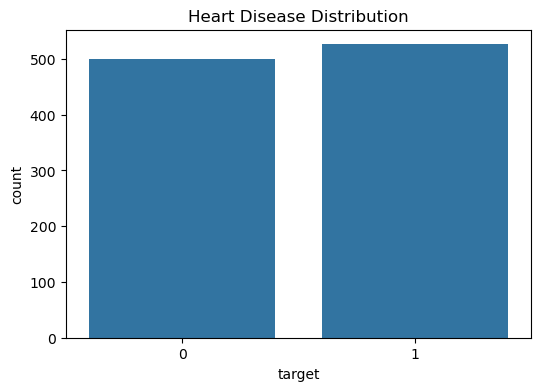

In [71]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=data)
plt.title("Heart Disease Distribution")
plt.show()

### Correlation Heatmap

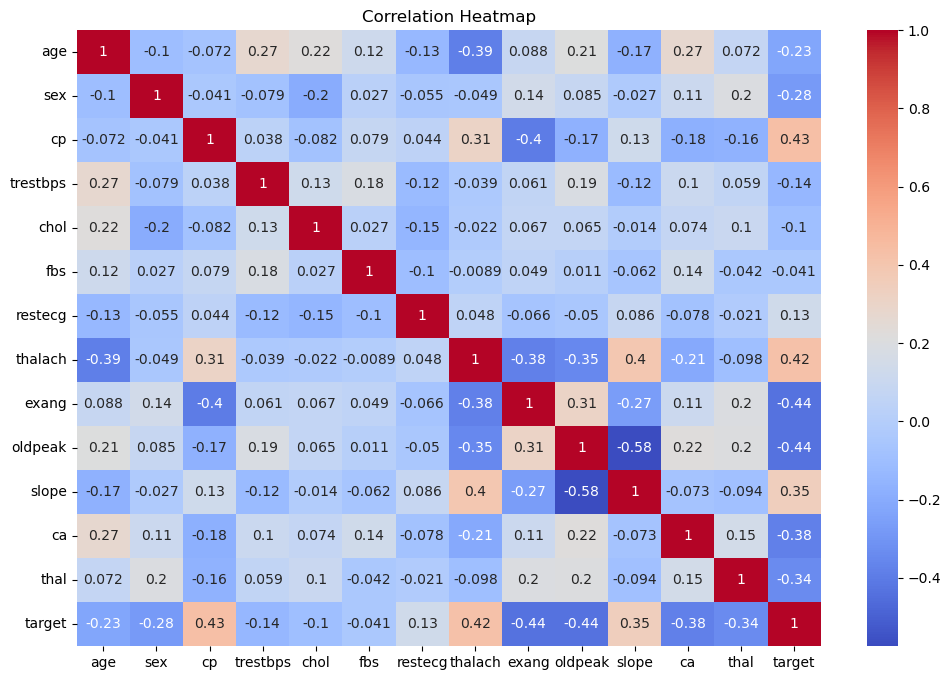

In [73]:

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


### Age Distribution

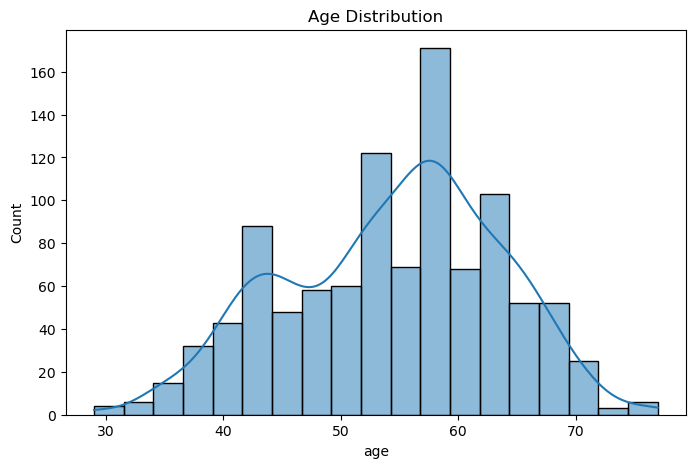

In [75]:

plt.figure(figsize=(8,5))
sns.histplot(data['age'], kde=True)
plt.title("Age Distribution")
plt.show()

###  Cholesterol Distribution

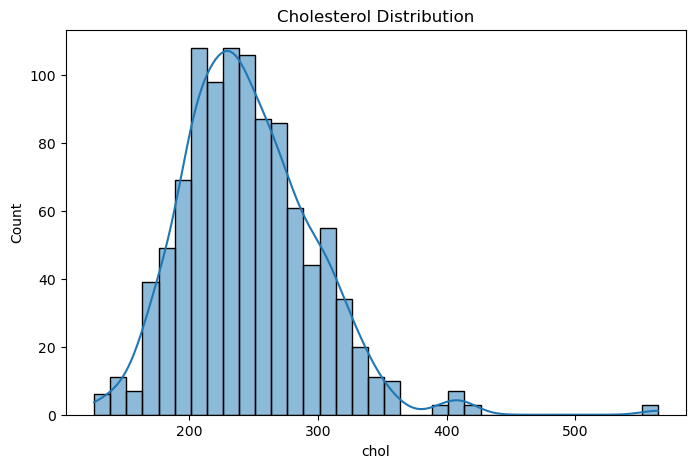

In [77]:

plt.figure(figsize=(8,5))
sns.histplot(data['chol'], kde=True)
plt.title("Cholesterol Distribution")
plt.show()

##  DEFINE FEATURES AND TARGET

In [79]:
X = data.drop('target', axis=1)
y = data['target']

### TRAIN TEST SPLIT

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### FEATURE SCALING

In [83]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## KNN MODEL WITHOUT TUNING

In [85]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

### EVALUATION

In [87]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy Score:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)




Accuracy Score:
0.8634146341463415

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       100
           1       0.87      0.86      0.87       105

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



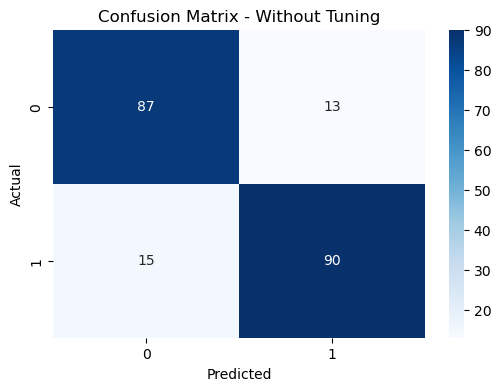

In [88]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Without Tuning")
plt.show()

### ROC AUC Score

In [90]:
roc_score = roc_auc_score(y_test, y_pred)

print("\nROC AUC Score:")
print(roc_score)


ROC AUC Score:
0.8635714285714285


## HYPERPARAMETER TUNING

In [92]:
param_grid = {
    'n_neighbors': [3,5,7,9,11,13],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
# Train GridSearch
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11, 13],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

#### BEST PARAMETERS

In [94]:
print("\nBest Parameters")
print(grid_search.best_params_)



Best Parameters
{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}


In [95]:
# Best Model
best_knn = grid_search.best_estimator_
# Prediction
y_pred_tuned = best_knn.predict(X_test)


## EVALUATION WITH TUNING

In [97]:
print("\n===== KNN WITH HYPERPARAMETER TUNING =====")
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print("\nTuned Accuracy Score:")
print(accuracy_tuned)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))



===== KNN WITH HYPERPARAMETER TUNING =====

Tuned Accuracy Score:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



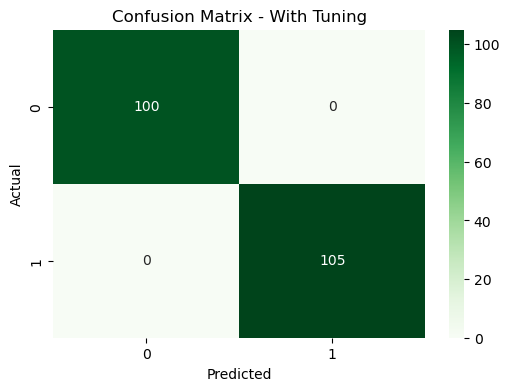

In [98]:

# Confusion Matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - With Tuning")
plt.show()


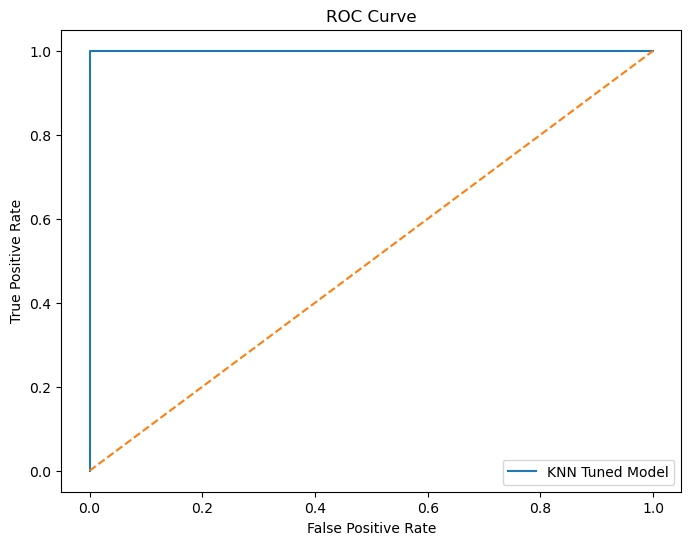

In [99]:
# ROC Curve
probabilities = best_knn.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, probabilities)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='KNN Tuned Model')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [100]:
# ROC AUC Score
roc_score_tuned = roc_auc_score(y_test, y_pred_tuned)

print("\nTuned ROC AUC Score:")
print(roc_score_tuned)



Tuned ROC AUC Score:
1.0


### FINAL COMPARISON

In [102]:
print("\n===== MODEL COMPARISON =====")

print("Accuracy Without Tuning :", accuracy)
print("Accuracy With Tuning    :", accuracy_tuned)


===== MODEL COMPARISON =====
Accuracy Without Tuning : 0.8634146341463415
Accuracy With Tuning    : 1.0


In [103]:
import pickle
pickle.dump(best_knn,open('model_knn.save1','wb'))
pickle.dump(scaler,open('scaler_knn.save1','wb'))

In [104]:
print(type(best_knn))
print(type(scaler))

<class 'sklearn.neighbors._classification.KNeighborsClassifier'>
<class 'sklearn.preprocessing._data.StandardScaler'>
